In [3]:
from functions import *
from constants import *
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

def integrate(params):
    Lr, Pr, Rr, Tr = params
    inner_conditions = load1(Pr, Tr)
    outer_conditions = load2(Lr, Rr)

    mass_range = np.linspace(Mc, M_star, num=1000) #mass from center to surface of star
    mass_out = mass_range[mass_range < M_fitting] ### the masses for the outward integration
    mass_in = np.flipud(mass_range[mass_range >= M_fitting]) ### the masses for the inward integration

    tspan_out = [mass_out[0], mass_out[-1]]
    tspan_in = [mass_in[0], mass_in[-1]]

    ### actually run the integrations and save ###
    print('Starting integration')
    int_out_soln = solve_ivp(derivs, t_span = tspan_out, y0 = inner_conditions, t_eval = mass_out, method='Radau',
                             rtol=1e-6, atol=1e-10)
    print('Outward integration worked.')
    int_in_soln = solve_ivp(derivs, t_span = tspan_in, y0 = outer_conditions, t_eval = mass_in, method='Radau',
                            rtol=1e-6, atol=1e-10)
    print('Inward integration worked.')

    return mass_out, mass_in, int_out_soln, int_in_soln

In [4]:
_,_, int_in_soln, int_out_soln = integrate(init_guess) #parameters from integrating inwards and outwards

Starting integration
Outward integration worked.
Inward integration worked.


In [5]:
print(int_in_soln.y[0])

[1.00095564e+26 9.66575847e+30 1.89303335e+31 2.79030008e+31
 3.66300988e+31 4.51407197e+31 5.34556910e+31 6.15910361e+31
 6.95596516e+31 7.73722613e+31 8.50379890e+31 9.25647368e+31
 9.99594547e+31 1.07228313e+32 1.14376854e+32 1.21410094e+32
 1.28332606e+32 1.35148567e+32 1.41861853e+32 1.48476012e+32
 1.54994383e+32 1.61420041e+32 1.67755896e+32 1.74004646e+32
 1.80168875e+32 1.86250958e+32 1.92253191e+32 1.98177734e+32
 2.04026609e+32 2.09801800e+32 2.15505133e+32 2.21138360e+32
 2.26703191e+32 2.32201238e+32 2.37634017e+32 2.43003019e+32
 2.48309679e+32 2.53555329e+32 2.58741273e+32 2.63868810e+32
 2.68939131e+32 2.73953378e+32 2.78912685e+32 2.83818158e+32
 2.88670853e+32 2.93471753e+32 2.98221841e+32 3.02922061e+32
 3.07573383e+32 3.12176659e+32 3.16732730e+32 3.21242440e+32
 3.25706601e+32 3.30126038e+32 3.34501495e+32 3.38833692e+32
 3.43123349e+32 3.47371176e+32 3.51577871e+32 3.55744105e+32
 3.59870501e+32 3.63957681e+32 3.68006266e+32 3.72016833e+32
 3.75990031e+32 3.799263

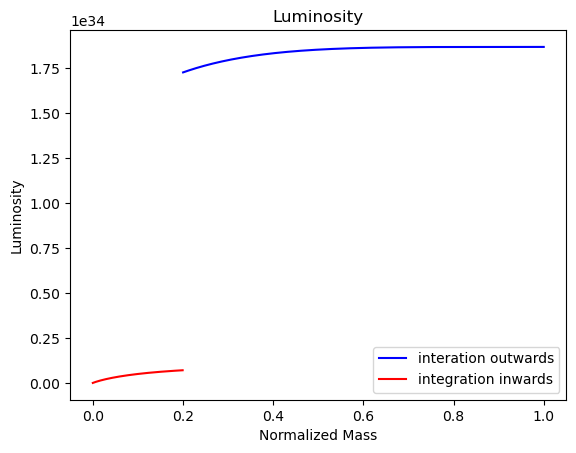

In [6]:
### Luminosity Plots ###
plt.plot(int_out_soln.t/M_star, int_out_soln.y[0], c = 'b', label = 'interation outwards')
plt.plot(int_in_soln.t/M_star, int_in_soln.y[0], c = 'r', label='integration inwards')
plt.title('Luminosity')
plt.xlabel('Normalized Mass')
plt.ylabel('Luminosity')
plt.legend()
plt.show()

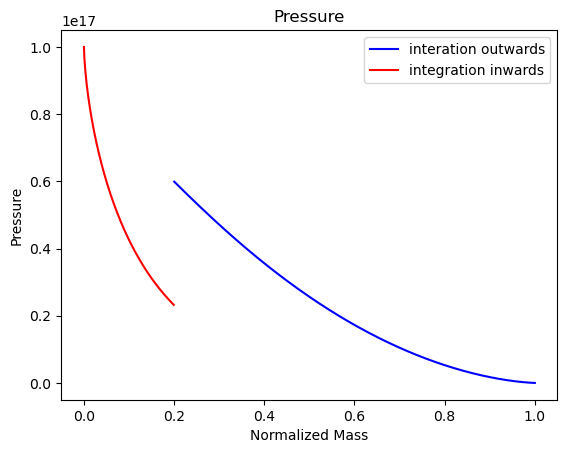

In [7]:
### Pressure Plots ###
plt.plot(int_out_soln.t/M_star, int_out_soln.y[1], c = 'b', label = 'interation outwards')
plt.plot(int_in_soln.t/M_star, int_in_soln.y[1], c = 'r', label='integration inwards')
plt.title('Pressure')
plt.xlabel('Normalized Mass')
plt.ylabel('Pressure')
plt.legend()
plt.show()

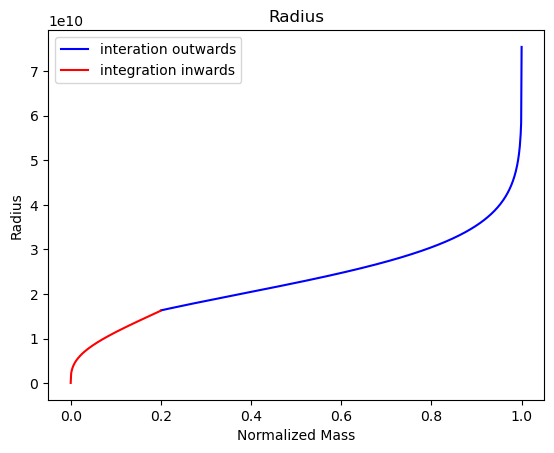

In [8]:
### Radius Plots ###
plt.plot(int_out_soln.t/M_star, int_out_soln.y[2], c = 'b', label = 'interation outwards')
plt.plot(int_in_soln.t/M_star, int_in_soln.y[2], c = 'r', label='integration inwards')
plt.title('Radius')
plt.xlabel('Normalized Mass')
plt.ylabel('Radius')
plt.legend()
plt.show()

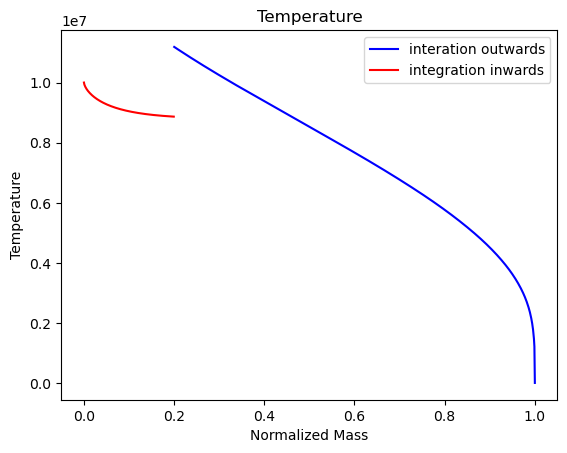

In [9]:
### Temperature Plots ###
plt.plot(int_out_soln.t/M_star, int_out_soln.y[3], c = 'b', label = 'interation outwards')
plt.plot(int_in_soln.t/M_star, int_in_soln.y[3], c = 'r', label='integration inwards')
plt.title('Temperature')
plt.xlabel('Normalized Mass')
plt.ylabel('Temperature')
plt.legend()
plt.show()